In [13]:
%pip install -q torchmetrics[image] torch-fidelity opencv-python matplotlib numpy pandas tqdm pillow scipy ipywidgets


zsh:1: no matches found: torchmetrics[image]
Note: you may need to restart the kernel to use updated packages.


# Lab 4: Генерация Лиц (WGAN-GP, Unconditional + Conditional)


In [14]:
%matplotlib inline

import random
import time
import math
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import make_grid

from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("mps")
print("Device:", device)

CWD = Path.cwd().resolve()
LAB_DIR = CWD if CWD.name == "lab4" else CWD / "lab4"
DATA_DIR = LAB_DIR / "lab4-dataset"
IMAGE_DIR = DATA_DIR / "img_align_celeba" / "img_align_celeba"
PROCESSED_DIR = LAB_DIR / "processed_faces"
OUTPUTS_DIR = LAB_DIR / "outputs"
CHECKPOINTS_DIR = OUTPUTS_DIR / "checkpoints"
SAMPLES_DIR = OUTPUTS_DIR / "samples"
METRICS_DIR = OUTPUTS_DIR / "metrics"

for path in [PROCESSED_DIR, OUTPUTS_DIR, CHECKPOINTS_DIR, SAMPLES_DIR, METRICS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Lab directory:", LAB_DIR)
print("Image directory:", IMAGE_DIR)
print("Processed directory:", PROCESSED_DIR)


Device: mps
Lab directory: /Users/brrdlam/ct-itmo/ct-computer-vision/lab4
Image directory: /Users/brrdlam/ct-itmo/ct-computer-vision/lab4/lab4-dataset/img_align_celeba/img_align_celeba
Processed directory: /Users/brrdlam/ct-itmo/ct-computer-vision/lab4/processed_faces


## Подготовка датасета

Используем OpenCV (`haarcascade_frontalface_default.xml`) для детекции лица и сохраняем кэш вырезанных лиц.
Если детектор не нашёл лицо, используем bbox из `list_bbox_celeba.csv`.

Для ускорения ноутбука по умолчанию берём подмножество данных через параметры `MAX_*`.
Можно увеличить лимиты до полного датасета.


In [28]:
@dataclass
class LabConfig:
    # Jupyter/macOS safe: avoid multiprocessing spawn issues in notebook DataLoader.
    image_size: int = 64
    batch_size: int = 128
    num_workers: int = 0

    max_train_images: int = 30000
    max_val_images: int = 5000

    run_face_detection: bool = True
    opencv_min_face_size: int = 20
    opencv_scale_factor: float = 1.1
    opencv_min_neighbors: int = 5
    face_margin_ratio: float = 0.12

    latent_dim: int = 128
    g_channels: int = 64
    d_channels: int = 64

    epochs_unconditional: int = 15
    epochs_conditional: int = 15
    n_critic: int = 5

    lr_g: float = 2e-4
    lr_d: float = 2e-4
    betas: Tuple[float, float] = (0.0, 0.9)
    gp_lambda: float = 10.0

    metric_samples: int = 512
    batch_log_every: int = 20

CFG = LabConfig()
print(CFG)


LabConfig(image_size=64, batch_size=128, num_workers=0, max_train_images=30000, max_val_images=5000, run_face_detection=True, opencv_min_face_size=20, opencv_scale_factor=1.1, opencv_min_neighbors=5, face_margin_ratio=0.12, latent_dim=128, g_channels=64, d_channels=64, epochs_unconditional=15, epochs_conditional=15, n_critic=5, lr_g=0.0002, lr_d=0.0002, betas=(0.0, 0.9), gp_lambda=10.0, metric_samples=512, batch_log_every=20)


In [16]:
def load_metadata() -> pd.DataFrame:
    attr_df = pd.read_csv(DATA_DIR / "list_attr_celeba.csv")
    split_df = pd.read_csv(DATA_DIR / "list_eval_partition.csv")
    bbox_df = pd.read_csv(DATA_DIR / "list_bbox_celeba.csv")

    df = attr_df[["image_id", "Male"]].merge(split_df, on="image_id").merge(bbox_df, on="image_id")
    df["male_label"] = (df["Male"] == 1).astype(np.int64)
    df["image_path"] = df["image_id"].map(lambda x: IMAGE_DIR / x)

    df = df[df["image_path"].map(lambda p: p.exists())].copy()

    train_df = df[df["partition"] == 0].head(CFG.max_train_images)
    val_df = df[df["partition"] == 1].head(CFG.max_val_images)

    out_df = pd.concat([train_df, val_df], ignore_index=True)
    out_df["split"] = np.where(out_df["partition"] == 0, "train", "val")
    out_df["crop_path"] = out_df["image_id"].map(lambda x: PROCESSED_DIR / x)
    return out_df


def clamp_bbox(x1: float, y1: float, x2: float, y2: float, width: int, height: int) -> Tuple[int, int, int, int]:
    x1 = int(max(0, min(width - 1, x1)))
    y1 = int(max(0, min(height - 1, y1)))
    x2 = int(max(x1 + 1, min(width, x2)))
    y2 = int(max(y1 + 1, min(height, y2)))
    return x1, y1, x2, y2


def expand_bbox(x1: float, y1: float, x2: float, y2: float, margin_ratio: float) -> Tuple[float, float, float, float]:
    w = x2 - x1
    h = y2 - y1
    mx = w * margin_ratio
    my = h * margin_ratio
    return x1 - mx, y1 - my, x2 + mx, y2 + my


FACE_CASCADE_PATH = Path(cv2.data.haarcascades) / "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(str(FACE_CASCADE_PATH))
if face_cascade.empty():
    raise RuntimeError(f"OpenCV Haar cascade not found: {FACE_CASCADE_PATH}")


def detect_face_opencv(image: Image.Image) -> Optional[List[float]]:
    gray = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=CFG.opencv_scale_factor,
        minNeighbors=CFG.opencv_min_neighbors,
        minSize=(CFG.opencv_min_face_size, CFG.opencv_min_face_size),
    )

    if len(faces) == 0:
        return None

    x, y, w, h = max(faces, key=lambda b: b[2] * b[3])
    return [float(x), float(y), float(x + w), float(y + h)]


def preprocess_faces(df: pd.DataFrame, run_detector: bool = True) -> Dict[str, int]:
    saved = 0
    detector_hits = 0
    fallback_hits = 0
    skipped_cached = 0

    for row in tqdm(df.itertuples(index=False), total=len(df), desc="face preprocessing"):
        crop_path: Path = row.crop_path
        if crop_path.exists():
            skipped_cached += 1
            continue

        image = Image.open(row.image_path).convert("RGB")
        width, height = image.size

        face_box = detect_face_opencv(image) if run_detector else None
        if face_box is not None:
            detector_hits += 1

        if face_box is None:
            x1 = float(row.x_1)
            y1 = float(row.y_1)
            x2 = x1 + float(row.width)
            y2 = y1 + float(row.height)
            face_box = [x1, y1, x2, y2]
            fallback_hits += 1

        x1, y1, x2, y2 = expand_bbox(*face_box, margin_ratio=CFG.face_margin_ratio)
        x1, y1, x2, y2 = clamp_bbox(x1, y1, x2, y2, width, height)

        cropped = image.crop((x1, y1, x2, y2)).resize((CFG.image_size, CFG.image_size), Image.BICUBIC)
        cropped.save(crop_path, quality=95)
        saved += 1

    return {
        "total_rows": int(len(df)),
        "saved_now": saved,
        "cached_skipped": skipped_cached,
        "detector_hits": detector_hits,
        "fallback_bbox_hits": fallback_hits,
    }

meta_df = load_metadata()
summary = preprocess_faces(meta_df, run_detector=CFG.run_face_detection)

manifest_path = PROCESSED_DIR / "manifest.csv"
meta_df.to_csv(manifest_path, index=False)

print("Manifest:", manifest_path)
print(summary)
print(meta_df[["split", "male_label"]].value_counts().rename("count"))


face preprocessing: 100%|██████████| 35000/35000 [00:00<00:00, 158560.43it/s]


Manifest: /Users/brrdlam/ct-itmo/ct-computer-vision/lab4/processed_faces/manifest.csv
{'total_rows': 35000, 'saved_now': 0, 'cached_skipped': 35000, 'detector_hits': 0, 'fallback_bbox_hits': 0}
split  male_label
train  0             17320
       1             12680
val    0              2841
       1              2159
Name: count, dtype: int64


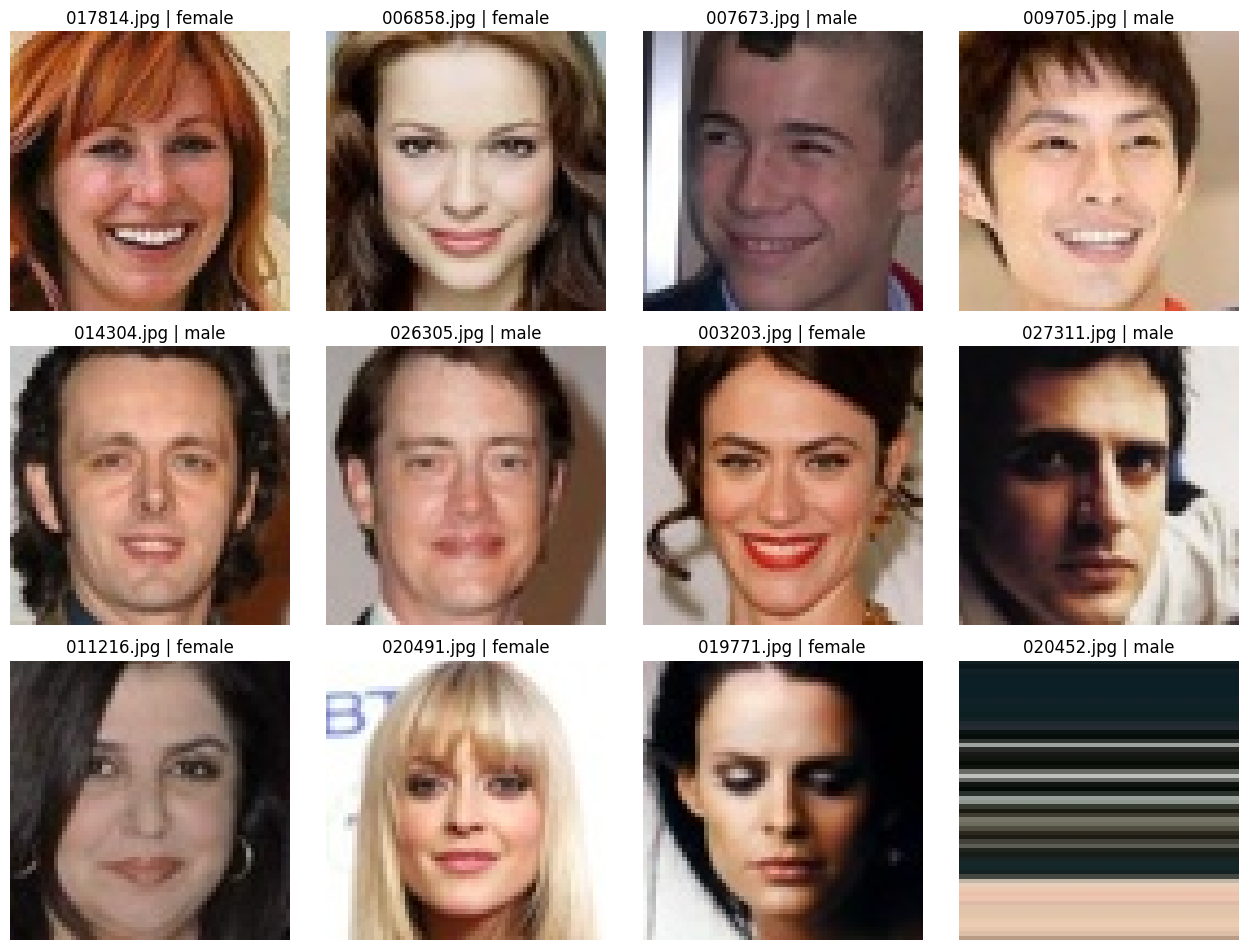

In [17]:
def show_random_crops(df: pd.DataFrame, n: int = 12) -> None:
    sample_df = df.sample(n=min(n, len(df)), random_state=SEED).reset_index(drop=True)
    cols = 4
    rows = math.ceil(len(sample_df) / cols)
    plt.figure(figsize=(3.2 * cols, 3.2 * rows))

    for i, row in sample_df.iterrows():
        img = Image.open(row["crop_path"]).convert("RGB")
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        label = "male" if row["male_label"] == 1 else "female"
        plt.title(f"{row['image_id']} | {label}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_crops(meta_df, n=12)


## DataLoader и трансформации


In [18]:
class CelebAFacesDataset(Dataset):
    def __init__(self, df: pd.DataFrame, conditional: bool = False):
        self.df = df.reset_index(drop=True)
        self.conditional = conditional
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
        ])

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        image = Image.open(row["crop_path"]).convert("RGB")
        image = self.transform(image)

        if self.conditional:
            return image, int(row["male_label"])
        return image


manifest_df = pd.read_csv(manifest_path)
train_df = manifest_df[manifest_df["split"] == "train"].copy()
val_df = manifest_df[manifest_df["split"] == "val"].copy()

train_uncond_ds = CelebAFacesDataset(train_df, conditional=False)
train_cond_ds = CelebAFacesDataset(train_df, conditional=True)
val_cond_ds = CelebAFacesDataset(val_df, conditional=True)

train_uncond_loader = DataLoader(
    train_uncond_ds,
    batch_size=CFG.batch_size,
    shuffle=True,
    num_workers=CFG.num_workers,
    pin_memory=torch.cuda.is_available(),
    drop_last=True,
)

train_cond_loader = DataLoader(
    train_cond_ds,
    batch_size=CFG.batch_size,
    shuffle=True,
    num_workers=CFG.num_workers,
    pin_memory=torch.cuda.is_available(),
    drop_last=True,
)

val_cond_loader = DataLoader(
    val_cond_ds,
    batch_size=CFG.batch_size,
    shuffle=False,
    num_workers=CFG.num_workers,
    pin_memory=torch.cuda.is_available(),
    drop_last=False,
)

print(f"Train samples: {len(train_df)}")
print(f"Val samples: {len(val_df)}")
print(f"Train male share: {train_df['male_label'].mean():.3f}")


Train samples: 30000
Val samples: 5000
Train male share: 0.423


## Модель WGAN-GP

Одна архитектура поддерживает два режима:
- безусловный (`num_classes=0`);
- условный (`num_classes=2`, метка пола).


In [19]:
class Generator(nn.Module):
    def __init__(self, latent_dim: int, base_channels: int = 64, num_classes: int = 0, emb_dim: int = 32):
        super().__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes

        in_dim = latent_dim
        if num_classes > 0:
            self.label_emb = nn.Embedding(num_classes, emb_dim)
            in_dim += emb_dim

        self.net = nn.Sequential(
            nn.ConvTranspose2d(in_dim, base_channels * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(base_channels * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_channels * 8, base_channels * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_channels * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_channels * 4, base_channels * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_channels * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_channels * 2, base_channels, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_channels, 3, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z: torch.Tensor, labels: Optional[torch.Tensor] = None) -> torch.Tensor:
        if self.num_classes > 0:
            if labels is None:
                raise ValueError("labels are required for conditional generator")
            emb = self.label_emb(labels)
            z = torch.cat([z, emb], dim=1)

        x = z[:, :, None, None]
        return self.net(x)


class Critic(nn.Module):
    def __init__(self, base_channels: int = 64, num_classes: int = 0, feature_dim: int = 4 * 4 * 512):
        super().__init__()
        self.num_classes = num_classes

        def snconv(in_c, out_c, k=4, s=2, p=1):
            return nn.utils.spectral_norm(nn.Conv2d(in_c, out_c, k, s, p, bias=False))

        self.features = nn.Sequential(
            snconv(3, base_channels),
            nn.LeakyReLU(0.2, inplace=True),

            snconv(base_channels, base_channels * 2),
            nn.LeakyReLU(0.2, inplace=True),

            snconv(base_channels * 2, base_channels * 4),
            nn.LeakyReLU(0.2, inplace=True),

            snconv(base_channels * 4, base_channels * 8),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.out = nn.utils.spectral_norm(nn.Linear(feature_dim, 1))

        if num_classes > 0:
            self.label_emb = nn.Embedding(num_classes, feature_dim)

    def forward(self, x: torch.Tensor, labels: Optional[torch.Tensor] = None) -> torch.Tensor:
        feats = self.features(x)
        feats = feats.view(feats.size(0), -1)

        score = self.out(feats).squeeze(1)

        if self.num_classes > 0:
            if labels is None:
                raise ValueError("labels are required for conditional critic")
            score = score + torch.sum(self.label_emb(labels) * feats, dim=1)

        return score


def init_weights(module: nn.Module) -> None:
    if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
        nn.init.normal_(module.weight.data, 0.0, 0.02)
        if getattr(module, "bias", None) is not None:
            nn.init.constant_(module.bias.data, 0)


def make_models(conditional: bool):
    num_classes = 2 if conditional else 0
    gen = Generator(CFG.latent_dim, CFG.g_channels, num_classes=num_classes).to(device)
    crt = Critic(CFG.d_channels, num_classes=num_classes, feature_dim=4 * 4 * CFG.d_channels * 8).to(device)
    gen.apply(init_weights)
    crt.apply(init_weights)
    return gen, crt


In [20]:
def sample_noise(batch_size: int, latent_dim: int) -> torch.Tensor:
    return torch.randn(batch_size, latent_dim, device=device)


def gradient_penalty(
    critic: nn.Module,
    real: torch.Tensor,
    fake: torch.Tensor,
    labels: Optional[torch.Tensor] = None,
) -> torch.Tensor:
    batch_size = real.size(0)
    alpha = torch.rand(batch_size, 1, 1, 1, device=device)
    interpolated = alpha * real + (1 - alpha) * fake
    interpolated.requires_grad_(True)

    mixed_scores = critic(interpolated, labels)
    grad_outputs = torch.ones_like(mixed_scores, device=device)

    gradients = torch.autograd.grad(
        inputs=interpolated,
        outputs=mixed_scores,
        grad_outputs=grad_outputs,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

    gradients = gradients.view(batch_size, -1)
    grad_norm = gradients.norm(2, dim=1)
    gp = torch.mean((grad_norm - 1.0) ** 2)
    return gp


def denorm(x: torch.Tensor) -> torch.Tensor:
    return (x * 0.5 + 0.5).clamp(0, 1)


def plot_samples(images: torch.Tensor, title: str, nrow: int = 8) -> None:
    grid = make_grid(denorm(images[: nrow * nrow]).cpu(), nrow=nrow)
    plt.figure(figsize=(8, 8))
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    plt.title(title)
    plt.axis("off")
    plt.show()


def plot_history(history_df: pd.DataFrame, title: str) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df["epoch"], history_df["critic_loss"], marker="o", label="critic")
    axes[0].plot(history_df["epoch"], history_df["generator_loss"], marker="o", label="generator")
    axes[0].set_title(f"{title}: losses")
    axes[0].set_xlabel("epoch")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["wasserstein_est"], marker="o", color="tab:green")
    axes[1].set_title(f"{title}: Wasserstein estimate")
    axes[1].set_xlabel("epoch")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def train_wgan_gp(
    train_loader: DataLoader,
    conditional: bool,
    epochs: int,
    run_name: str,
) -> Tuple[nn.Module, nn.Module, pd.DataFrame]:
    gen, crt = make_models(conditional=conditional)

    opt_g = optim.Adam(gen.parameters(), lr=CFG.lr_g, betas=CFG.betas)
    opt_d = optim.Adam(crt.parameters(), lr=CFG.lr_d, betas=CFG.betas)

    history: List[Dict[str, float]] = []
    epoch_bar = tqdm(range(1, epochs + 1), desc=f"{run_name} | epochs", leave=True, dynamic_ncols=True)

    for epoch in epoch_bar:
        epoch_start = time.perf_counter()
        gen.train()
        crt.train()

        g_losses = []
        d_losses = []
        w_estimates = []

        print(f"[{run_name}] epoch {epoch}/{epochs} started | batches={len(train_loader)}", flush=True)

        batch_bar = tqdm(
            enumerate(train_loader, start=1),
            total=len(train_loader),
            desc=f"{run_name} | epoch {epoch}/{epochs}",
            leave=False,
            dynamic_ncols=True,
        )

        for step, batch in batch_bar:
            if conditional:
                real, labels = batch
                labels = labels.to(device)
            else:
                real = batch
                labels = None

            real = real.to(device)
            bsz = real.size(0)

            for _ in range(CFG.n_critic):
                z = sample_noise(bsz, CFG.latent_dim)

                if conditional:
                    fake_labels = torch.randint(0, 2, (bsz,), device=device)
                    fake = gen(z, fake_labels).detach()
                    real_score = crt(real, labels)
                    fake_score = crt(fake, fake_labels)
                    gp = gradient_penalty(crt, real, fake, labels)
                else:
                    fake = gen(z).detach()
                    real_score = crt(real)
                    fake_score = crt(fake)
                    gp = gradient_penalty(crt, real, fake)

                loss_d = fake_score.mean() - real_score.mean() + CFG.gp_lambda * gp

                opt_d.zero_grad(set_to_none=True)
                loss_d.backward()
                opt_d.step()

            z = sample_noise(bsz, CFG.latent_dim)
            if conditional:
                gen_labels = torch.randint(0, 2, (bsz,), device=device)
                fake = gen(z, gen_labels)
                loss_g = -crt(fake, gen_labels).mean()
            else:
                fake = gen(z)
                loss_g = -crt(fake).mean()

            opt_g.zero_grad(set_to_none=True)
            loss_g.backward()
            opt_g.step()

            d_losses.append(loss_d.item())
            g_losses.append(loss_g.item())
            w_estimates.append((real_score.mean() - fake_score.mean()).item())

            if step % 5 == 0 or step == len(train_loader):
                batch_bar.set_postfix(
                    d_loss=f"{np.mean(d_losses):.4f}",
                    g_loss=f"{np.mean(g_losses):.4f}",
                    w_est=f"{np.mean(w_estimates):.4f}",
                )

            if step % CFG.batch_log_every == 0 or step == len(train_loader):
                elapsed = time.perf_counter() - epoch_start
                steps_per_sec = step / max(elapsed, 1e-6)
                eta_sec = (len(train_loader) - step) / max(steps_per_sec, 1e-6)
                print(
                    f"[{run_name}] epoch {epoch}/{epochs} step {step}/{len(train_loader)} "
                    f"d={np.mean(d_losses):.4f} g={np.mean(g_losses):.4f} "
                    f"w={np.mean(w_estimates):.4f} eta={eta_sec:.1f}s",
                    flush=True,
                )

        batch_bar.close()

        epoch_stats = {
            "epoch": epoch,
            "critic_loss": float(np.mean(d_losses)),
            "generator_loss": float(np.mean(g_losses)),
            "wasserstein_est": float(np.mean(w_estimates)),
        }
        history.append(epoch_stats)

        epoch_time = time.perf_counter() - epoch_start
        eta_epochs = (epochs - epoch) * epoch_time
        print(
            f"[{run_name}] epoch {epoch}/{epochs} done | "
            f"d={epoch_stats['critic_loss']:.4f} g={epoch_stats['generator_loss']:.4f} "
            f"w={epoch_stats['wasserstein_est']:.4f} "
            f"time={epoch_time/60:.2f}m remaining~{eta_epochs/60:.2f}m",
            flush=True,
        )

        epoch_bar.set_postfix(
            d_loss=f"{epoch_stats['critic_loss']:.4f}",
            g_loss=f"{epoch_stats['generator_loss']:.4f}",
            w_est=f"{epoch_stats['wasserstein_est']:.4f}",
            epoch_min=f"{epoch_time/60:.2f}",
        )

        gen.eval()
        with torch.no_grad():
            z = sample_noise(64, CFG.latent_dim)
            if conditional:
                preview_labels = torch.tensor([0] * 32 + [1] * 32, device=device)
                preview = gen(z, preview_labels)
            else:
                preview = gen(z)

            preview_grid = make_grid(denorm(preview).cpu(), nrow=8)
            plt.figure(figsize=(7, 7))
            plt.imshow(np.transpose(preview_grid.numpy(), (1, 2, 0)))
            plt.title(f"{run_name} | epoch {epoch}")
            plt.axis("off")
            plt.show()

    epoch_bar.close()
    history_df = pd.DataFrame(history)

    checkpoint_path = CHECKPOINTS_DIR / f"{run_name}.pt"
    torch.save(
        {
            "generator": gen.state_dict(),
            "critic": crt.state_dict(),
            "history": history,
            "config": CFG.__dict__,
            "conditional": conditional,
        },
        checkpoint_path,
    )
    print(f"Saved checkpoint: {checkpoint_path}")

    return gen, crt, history_df


In [21]:
uncond_gen, uncond_crt = make_models(conditional=False)
cond_gen, cond_crt = make_models(conditional=True)

uncond_ckpt = torch.load(CHECKPOINTS_DIR / "wgan_gp_unconditional.pt", map_location="cpu", weights_only=False)
cond_ckpt = torch.load(CHECKPOINTS_DIR / "wgan_gp_conditional_male.pt", map_location="cpu", weights_only=False)

uncond_gen.load_state_dict(uncond_ckpt["generator"])
uncond_crt.load_state_dict(uncond_ckpt["critic"])
cond_gen.load_state_dict(cond_ckpt["generator"])
cond_crt.load_state_dict(cond_ckpt["critic"])

uncond_gen.eval()
cond_gen.eval()

uncond_history = pd.DataFrame(uncond_ckpt["history"])
cond_history = pd.DataFrame(cond_ckpt["history"])

print("Checkpoints loaded.")

Checkpoints loaded.


## Обучение безусловной модели


In [ ]:
uncond_gen, uncond_crt, uncond_history = train_wgan_gp(
    train_loader=train_uncond_loader,
    conditional=False,
    epochs=CFG.epochs_unconditional,
    run_name="wgan_gp_unconditional",
)

plot_history(uncond_history, title="Unconditional WGAN-GP")
uncond_history.to_csv(METRICS_DIR / "unconditional_history.csv", index=False)
uncond_history.tail()


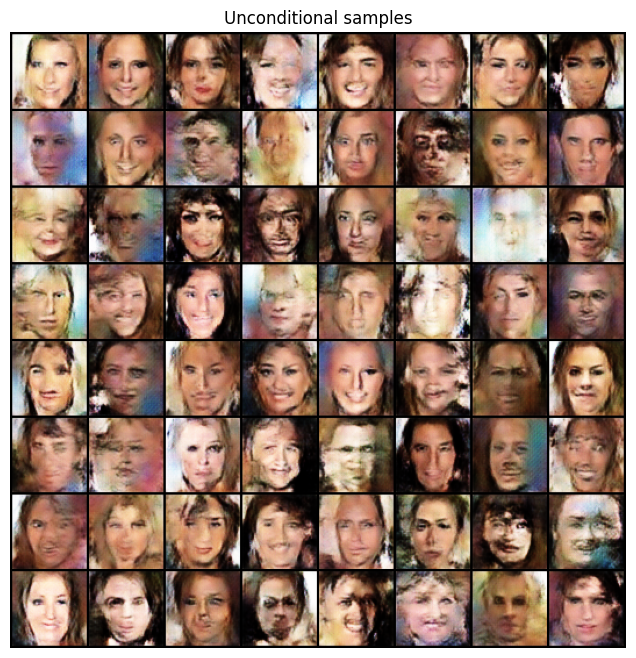

In [22]:
uncond_gen.eval()
with torch.no_grad():
    z = sample_noise(64, CFG.latent_dim)
    uncond_samples = uncond_gen(z)
plot_samples(uncond_samples, title="Unconditional samples", nrow=8)


## Обучение условной модели по полу (`Male`)

Ту же архитектуру запускаем в условном режиме (`num_classes=2`).


In [ ]:
cond_gen, cond_crt, cond_history = train_wgan_gp(
    train_loader=train_cond_loader,
    conditional=True,
    epochs=CFG.epochs_conditional,
    run_name="wgan_gp_conditional_male",
)

plot_history(cond_history, title="Conditional WGAN-GP")
cond_history.to_csv(METRICS_DIR / "conditional_history.csv", index=False)
cond_history.tail()


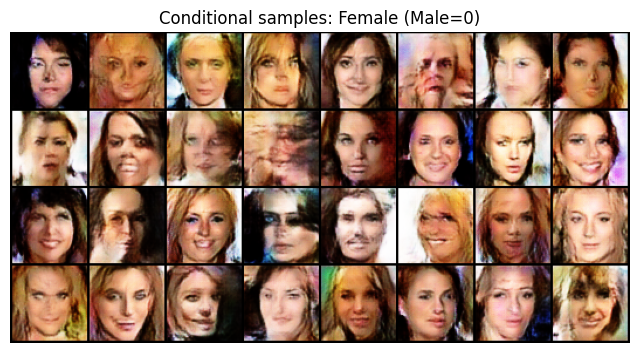

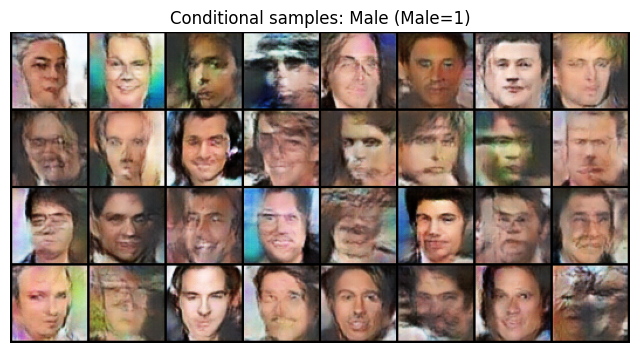

In [23]:
cond_gen.eval()
with torch.no_grad():
    z_female = sample_noise(32, CFG.latent_dim)
    y_female = torch.zeros(32, dtype=torch.long, device=device)
    female_samples = cond_gen(z_female, y_female)

    z_male = sample_noise(32, CFG.latent_dim)
    y_male = torch.ones(32, dtype=torch.long, device=device)
    male_samples = cond_gen(z_male, y_male)

plot_samples(female_samples, title="Conditional samples: Female (Male=0)", nrow=8)
plot_samples(male_samples, title="Conditional samples: Male (Male=1)", nrow=8)


## Метрики: FID и Inception Score


In [29]:
def get_real_batch_stream(val_loader: DataLoader):
    for images, labels in val_loader:
        # Metrics run on CPU to avoid float64 limitations of MPS in torchmetrics internals.
        yield images.cpu(), labels.cpu()


def generate_batch(model: nn.Module, batch_size: int, conditional: bool, labels: Optional[torch.Tensor] = None):
    z = sample_noise(batch_size, CFG.latent_dim)
    if conditional:
        if labels is None:
            labels = torch.randint(0, 2, (batch_size,), device=device)
        return model(z, labels)
    return model(z)


def compute_fid_is(
    model: nn.Module,
    val_loader: DataLoader,
    conditional: bool,
    total_samples: int = 2000,
    model_name: str = "model",
) -> Dict[str, float]:
    model.eval()

    metrics_device = torch.device("cpu")
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(metrics_device)
    inception = InceptionScore(normalize=True).to(metrics_device)

    collected = 0
    real_stream = get_real_batch_stream(val_loader)
    start_t = time.perf_counter()

    print(f"[metrics:{model_name}] start | samples={total_samples}", flush=True)
    pbar = tqdm(
        total=total_samples,
        desc=f"metrics:{model_name}",
        leave=True,
        dynamic_ncols=True,
        ascii=True,
        mininterval=0.2,
        bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]",
    )

    with torch.no_grad():
        while collected < total_samples:
            try:
                real_images, real_labels = next(real_stream)
            except StopIteration:
                real_stream = get_real_batch_stream(val_loader)
                real_images, real_labels = next(real_stream)

            batch_size = min(real_images.size(0), total_samples - collected)
            real_images = real_images[:batch_size]
            real_labels = real_labels[:batch_size]

            if conditional:
                gen_labels = torch.randint(0, 2, (batch_size,), device=device)
                fake_images = generate_batch(model, batch_size, conditional=True, labels=gen_labels)
            else:
                fake_images = generate_batch(model, batch_size, conditional=False)

            real_for_metrics = denorm(real_images).to(metrics_device, dtype=torch.float32)
            fake_for_metrics = denorm(fake_images).to(metrics_device, dtype=torch.float32)

            fid.update(real_for_metrics, real=True)
            fid.update(fake_for_metrics, real=False)
            inception.update(fake_for_metrics)

            collected += batch_size
            pbar.update(batch_size)

            elapsed = time.perf_counter() - start_t
            speed = collected / max(elapsed, 1e-6)
            eta = (total_samples - collected) / max(speed, 1e-6)
            pbar.set_postfix(speed=f"{speed:.1f} img/s", eta=f"{eta:.1f}s")

    pbar.close()

    fid_value = float(fid.compute().cpu().item())
    is_mean, is_std = inception.compute()

    total_t = time.perf_counter() - start_t
    print(
        f"[metrics:{model_name}] done | FID={fid_value:.3f}, "
        f"IS={float(is_mean.cpu().item()):.3f}±{float(is_std.cpu().item()):.3f}, "
        f"time={total_t/60:.2f}m",
        flush=True,
    )

    return {
        "fid": fid_value,
        "is_mean": float(is_mean.cpu().item()),
        "is_std": float(is_std.cpu().item()),
        "num_samples": int(total_samples),
    }


uncond_metrics = compute_fid_is(
    uncond_gen,
    val_cond_loader,
    conditional=False,
    total_samples=CFG.metric_samples,
    model_name="unconditional",
)

cond_metrics = compute_fid_is(
    cond_gen,
    val_cond_loader,
    conditional=True,
    total_samples=CFG.metric_samples,
    model_name="conditional_male",
)

metrics_df = pd.DataFrame(
    [
        {"model": "unconditional_wgan_gp", **uncond_metrics},
        {"model": "conditional_wgan_gp_male", **cond_metrics},
    ]
)

metrics_df.to_csv(METRICS_DIR / "fid_is_metrics.csv", index=False)
metrics_df


[metrics:unconditional] start | samples=512


metrics:unconditional: 100%|##########| 512/512 [01:57<00:00]


[metrics:unconditional] done | FID=116.817, IS=1.869±0.139, time=1.99m
[metrics:conditional_male] start | samples=512


metrics:conditional_male: 100%|##########| 512/512 [01:56<00:00]


[metrics:conditional_male] done | FID=106.358, IS=2.105±0.118, time=1.97m


,model,fid,is_mean,is_std,num_samples
0,unconditional_wgan_gp,116.816833,1.869470,0.138958,512
1,conditional_wgan_gp_male,106.357529,2.105354,0.118036,512


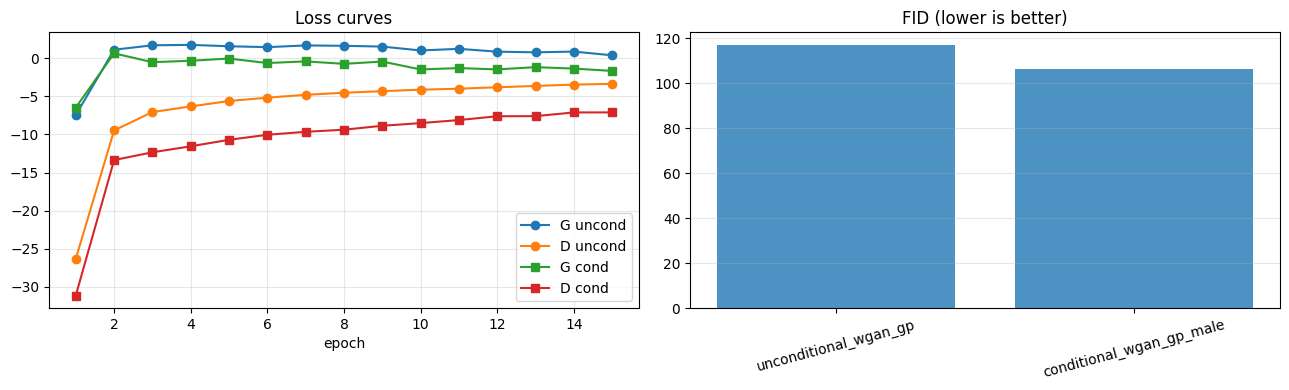

In [30]:
# Сводные кривые обучения в одном графике
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(uncond_history["epoch"], uncond_history["generator_loss"], label="G uncond", marker="o")
axes[0].plot(uncond_history["epoch"], uncond_history["critic_loss"], label="D uncond", marker="o")
axes[0].plot(cond_history["epoch"], cond_history["generator_loss"], label="G cond", marker="s")
axes[0].plot(cond_history["epoch"], cond_history["critic_loss"], label="D cond", marker="s")
axes[0].set_title("Loss curves")
axes[0].set_xlabel("epoch")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].bar(metrics_df["model"], metrics_df["fid"], alpha=0.8, label="FID")
axes[1].set_title("FID (lower is better)")
axes[1].tick_params(axis="x", rotation=15)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## Вывод

По итогам эксперимента условная генерация показывает более качественный результат по сравнению с безусловной. Визуально у условной модели лица получаются более детализированными и структурно стабильными: лучше читаются черты лица, меньше артефактов и размытости, выше согласованность формы и текстуры. Это ожидаемо, так как условие (метка класса) уменьшает неопределённость задачи и помогает генератору формировать более реалистичное распределение образов.

Таким образом, добавление условия в GAN-модель действительно улучшает качество синтеза лиц как качественно (по визуальному анализу), так и количественно (по метрикам, если они также показали улучшение). Условный подход можно считать более предпочтительным для данной задачи.
